<a href="https://colab.research.google.com/github/adhikaryramen87/MachineLearning_Works/blob/main/Normalization_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train/255.0
X_test = X_test/255.0

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)


In [10]:
model = models.Sequential([
    layers.Dense(256, input_shape=(28*28,)),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.ReLU(),

    layers.Dense(10, activation='softmax')
])


In [11]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [12]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9374 - loss: 0.2154 - val_accuracy: 0.9760 - val_loss: 0.0900
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9741 - loss: 0.0858 - val_accuracy: 0.9757 - val_loss: 0.0812
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9819 - loss: 0.0581 - val_accuracy: 0.9810 - val_loss: 0.0660
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9852 - loss: 0.0472 - val_accuracy: 0.9797 - val_loss: 0.0719
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9883 - loss: 0.0365 - val_accuracy: 0.9757 - val_loss: 0.0847
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9902 - loss: 0.0300 - val_accuracy: 0.9820 - val_loss: 0.0663
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9922 - loss: 0.0240 - val_accuracy: 0.9790 - val_loss: 0.0736
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9914 - loss: 0.0242 - val_accuracy: 

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',      # metric to watch (can be 'val_accuracy' too)
    patience=3,              # number of epochs with no improvement before stopping
    restore_best_weights=True # roll back to best weights
)

# Fit model with early stopping
history = model.fit(
    X_train, y_train,
    epochs=50,               # set a higher max epoch, early stop will cut it short
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9952 - loss: 0.0143 - val_accuracy: 0.9830 - val_loss: 0.0723
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9832 - val_loss: 0.0696
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9949 - loss: 0.0157 - val_accuracy: 0.9823 - val_loss: 0.0785
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9959 - loss: 0.0111 - val_accuracy: 0.9827 - val_loss: 0.0793
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9813 - val_loss: 0.0778


In [16]:
predictions= model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
print(predicted_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]


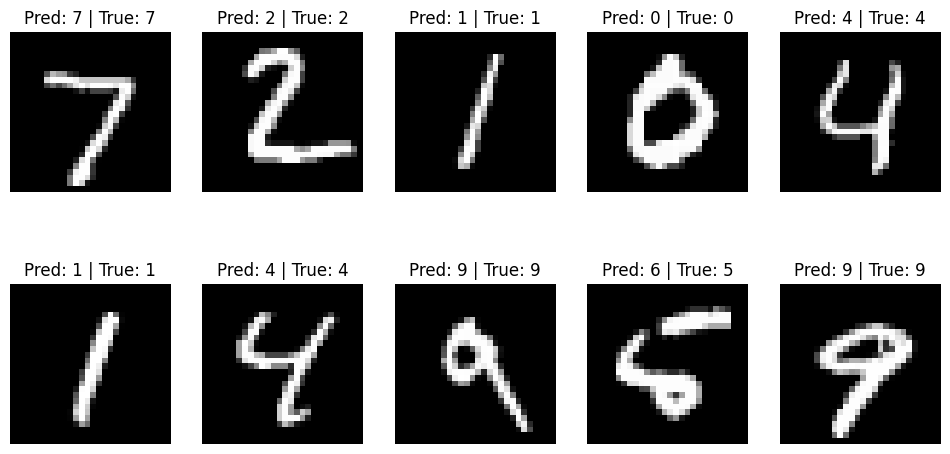

In [17]:
import matplotlib.pyplot as plt

def show_predictions(x, y_true, y_pred, num_images=10):
  plt.figure(figsize=(12, 6))

  for i in range(num_images):
    plt.subplot(2, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap='gray')
    plt.title(f'Pred: {y_pred[i]} | True: {y_true[i]}')
    plt.axis('off')

  plt.show()

# call function
show_predictions(X_test, y_test, predicted_labels, num_images=10)